In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LSTM,
    Input,
    Attention,
    Flatten,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("creditcard.csv")

print(df.shape)

df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
fraud = df["Class"].value_counts()[1]
legit = df["Class"].value_counts()[0]

total = len(df)

fraud_percent = fraud/total*100
legit_percent = legit/total*100

print("Fraud % :", fraud_percent)
print("Legitimate % :", legit_percent)

print("Class Imbalance Ratio :")
print(f"{legit}:{fraud}")

Fraud % : 0.1727485630620034
Legitimate % : 99.82725143693798
Class Imbalance Ratio :
284315:492


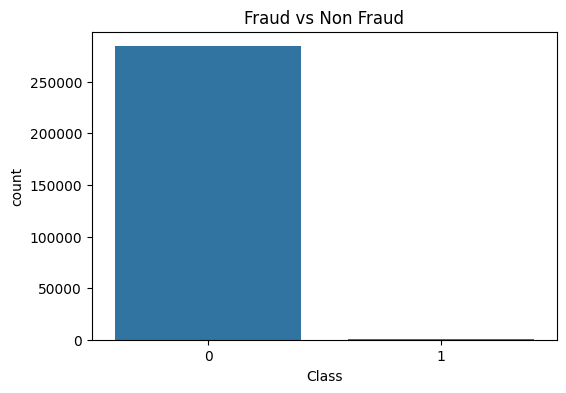

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Class",
    data=df
)

plt.title("Fraud vs Non Fraud")
plt.show()

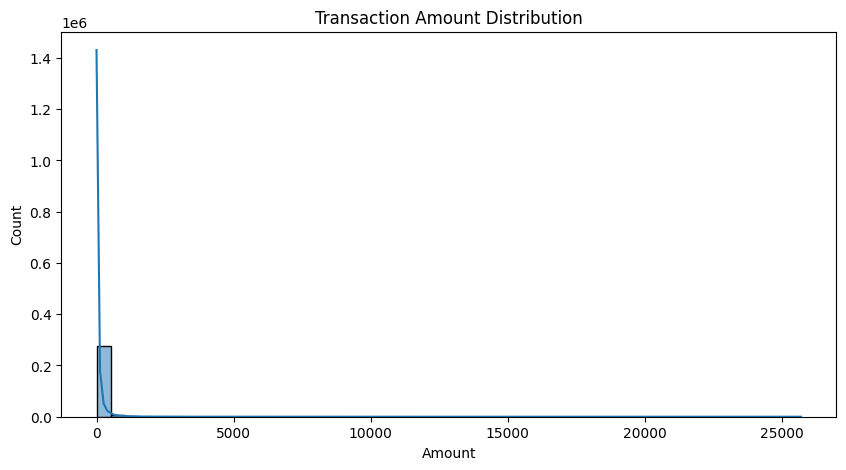

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Amount"],
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.show()

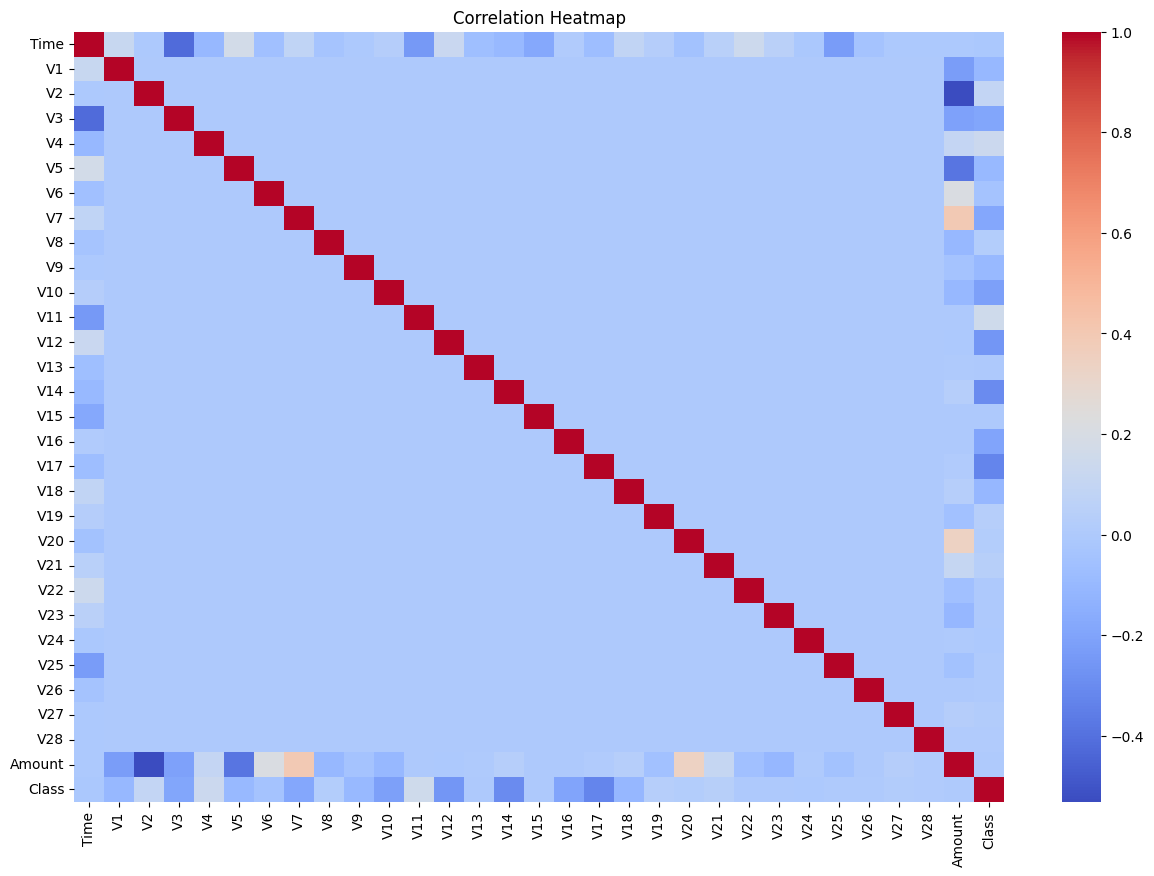

In [8]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [9]:
df = df.sort_values("Time")
df = df.reset_index(drop=True)

In [10]:
scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(
    df[["Amount"]]
)

In [11]:
X = df.drop("Class", axis=1).values

y = df["Class"].values

In [12]:
SEQ_LEN = 5

X_seq = []
y_seq = []

for i in range(len(X)-SEQ_LEN):

    X_seq.append(
        X[i:i+SEQ_LEN]
    )

    y_seq.append(
        y[i+SEQ_LEN]
    )

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape)
print(y_seq.shape)

(284802, 5, 30)
(284802,)


In [13]:
X_train,X_test,y_train,y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)

In [14]:
X_train_dense = X_train.reshape(
    X_train.shape[0],
    -1
)

X_test_dense = X_test.reshape(
    X_test.shape[0],
    -1
)

In [15]:
dense_model = Sequential([

    Dense(128,activation="relu"),

    Dropout(0.3),

    Dense(64,activation="relu"),

    Dense(1,activation="sigmoid")
])

dense_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dense_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
dense_model.fit(
    X_train_dense,
    y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9936 - loss: 85.9434 - val_accuracy: 0.9982 - val_loss: 15.3632
Epoch 2/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9967 - loss: 10.5071 - val_accuracy: 0.9982 - val_loss: 3.2157
Epoch 3/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9967 - loss: 4.9818 - val_accuracy: 0.9982 - val_loss: 3.1667
Epoch 4/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9967 - loss: 3.1285 - val_accuracy: 0.9982 - val_loss: 4.6167
Epoch 5/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9968 - loss: 2.8747 - val_accuracy: 0.9982 - val_loss: 0.8518


In [17]:
lstm_model = Sequential([

    LSTM(
        64,
        return_sequences=False
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9885 - loss: 0.0350 - val_accuracy: 0.9982 - val_loss: 0.0131
Epoch 2/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9983 - loss: 0.0127 - val_accuracy: 0.9982 - val_loss: 0.0130
Epoch 3/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9983 - loss: 0.0127 - val_accuracy: 0.9982 - val_loss: 0.0130
Epoch 4/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9983 - loss: 0.0127 - val_accuracy: 0.9982 - val_loss: 0.0132
Epoch 5/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9983 - loss: 0.0127 - val_accuracy: 0.9982 - val_loss: 0.0133


In [19]:
inputs = Input(
    shape=(SEQ_LEN,30)
)

x = LSTM(
    64,
    return_sequences=True
)(inputs)

attention = Attention()(
    [x,x]
)

x = Flatten()(attention)

x = Dense(
    64,
    activation="relu"
)(x)

outputs = Dense(
    1,
    activation="sigmoid"
)(x)

attention_model = Model(
    inputs,
    outputs
)

attention_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

attention_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 5, 30)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 5, 64)     │     24,320 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 5, 64)     │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 320)       │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     20,544 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 44,929 (175.50 KB)

 Trainable params: 44,929 (175.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
attention_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9983 - loss: 0.0158 - val_accuracy: 0.9982 - val_loss: 0.0144
Epoch 2/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9983 - loss: 0.0131 - val_accuracy: 0.9982 - val_loss: 0.0136
Epoch 3/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9983 - loss: 0.0129 - val_accuracy: 0.9982 - val_loss: 0.0132
Epoch 4/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9983 - loss: 0.0129 - val_accuracy: 0.9982 - val_loss: 0.0143
Epoch 5/5
712/712 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9983 - loss: 0.0129 - val_accuracy: 0.9982 - val_loss: 0.0131


In [21]:
def positional_encoding(
        length,
        depth):

    depth = depth/2

    positions = np.arange(length)[:,np.newaxis]

    depths = np.arange(depth)[np.newaxis,:]/depth

    angle_rates = 1/(10000**depths)

    angle_rads = positions*angle_rates

    pos_encoding = np.concatenate(
        [
            np.sin(angle_rads),
            np.cos(angle_rads)
        ],
        axis=-1
    )

    return tf.cast(
        pos_encoding,
        dtype=tf.float32
    )

In [22]:
PE = positional_encoding(
    SEQ_LEN,
    30
)

PE.shape

TensorShape([5, 30])

In [23]:
sample = X_train[:1]

sample_tensor = tf.convert_to_tensor(
    sample,
    dtype=tf.float32
)

position_aware = sample_tensor + PE

print(position_aware.shape)

(1, 5, 30)


In [24]:
sample = X_test[:1]

prediction = attention_model.predict(
    sample
)

print(
    "Fraud Probability:",
    prediction[0][0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Fraud Probability: 0.0022190497


In [25]:
attention_layer = Model(
    attention_model.input,
    attention_model.layers[2].output
)

weights = attention_layer.predict(
    sample
)

print(weights.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
(1, 5, 64)


In [26]:
dense_model.save(
    "dense_model.keras"
)

lstm_model.save(
    "lstm_model.keras"
)

attention_model.save(
    "attention_model.keras"
)

In [27]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']